In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#MACHINE LEARNING PREPARATION TOOLS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#OUR MACHINE LEARNING MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import joblib

#DATA BALANCING (SMOTE), SMOTE FIXES IMBALANCED DATA. IF WE HAVE VERY FEW "HIGH RISK" EMPLOYEES IN OUR DATASET, SMOTE CREATES SYNTHETIC/FAKE EXAMPLES SO THE AI LEARNS FAIRLY.
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [ ]:
df = pd.read_csv('work_from_home_burnout_dataset.csv')
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [ ]:
# DROP UNNECESSARY COLUMNS
df = df.drop(columns=['user_id', 'burnout_score'])

# HANDLING MISSING DATA (CLEANING)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# CATEGORICAL ENCODING (TEXT TO NUMBERS)
df['day_type'] = df['day_type'].map({'Weekday': 1, 'Weekend': 0})
df['after_hours_work'] = df['after_hours_work'].map({'Yes': 1, 'No': 0})

# HANDLE ANY MAPPING ERRORS
df = df.fillna(0)

# FEATURE SELECTION
features_to_use = ['day_type', 'work_hours', 'screen_time_hours', 'meetings_count',
                   'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate']

X = df[features_to_use]
y = df['burnout_risk']

# TARGET ENCODING & SCALING
le = LabelEncoder()
y_encoded = le.fit_transform(df['burnout_risk'])
class_names = le.classes_
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X)

In [ ]:
#SPLITTING THE DATA
X_train, X_test, y_train, y_test = train_test_split(X_test_scaled, y_encoded, test_size=0.2, random_state=42)

# APPLYING SMOTE TO FIX CLASS IMBALANCE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# MODEL 1: LOGISTIC REGRESSION
lr_model = LogisticRegression(multi_class='multinomial',
                              max_iter=1000)
lr_model.fit(X_train_res, y_train_res)
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# MODEL 2: RANDOM FOREST
rf_model = RandomForestClassifier(n_estimators=100,
                                  class_weight='balanced_subsample',
                                  random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

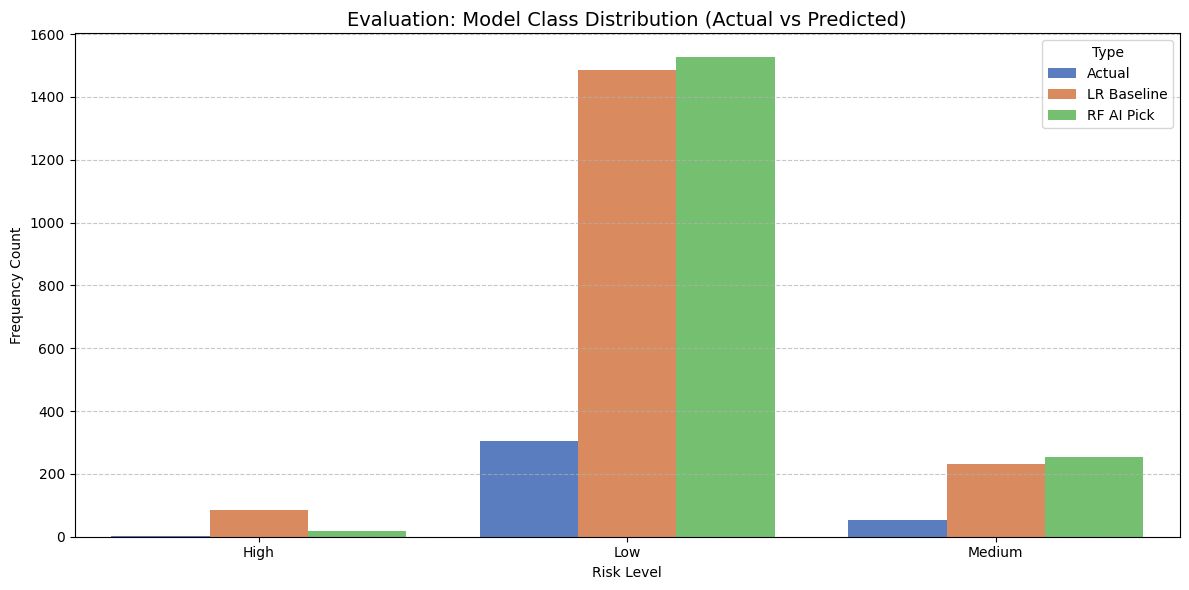

In [ ]:
# TRANSLATING PREDICTIONS BACK TO TEXT
actual_counts = pd.Series(le.inverse_transform(y_test)).value_counts().sort_index()
lr_counts = pd.Series(le.inverse_transform(y_pred_lr)).value_counts().sort_index()
rf_counts = pd.Series(le.inverse_transform(y_pred_rf)).value_counts().sort_index()


# GRAPH STRUCTURE
dist_df = pd.DataFrame({
    'Risk Level': actual_counts.index,
    'Actual': actual_counts.values,
    'LR Baseline': lr_counts.reindex(actual_counts.index, fill_value=0).values,
    'RF AI Pick': rf_counts.reindex(actual_counts.index, fill_value=0).values
})

# MELT DATA FOR VISUALIZATION
dist_melted = dist_df.melt(id_vars='Risk Level', var_name='Type', value_name='Count')


plt.figure(figsize=(12, 6))
sns.barplot(data=dist_melted, x='Risk Level', y='Count', hue='Type', palette='muted')
plt.title('Evaluation: Model Class Distribution (Actual vs Predicted)', fontsize=14)
plt.ylabel('Frequency Count')
plt.xlabel('Risk Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# TRANSLATING NUMBERS BACK TO WORDS
actual_labels = le.inverse_transform(y_test)
lr_labels = le.inverse_transform(y_pred_lr)
rf_labels = le.inverse_transform(y_pred_rf)

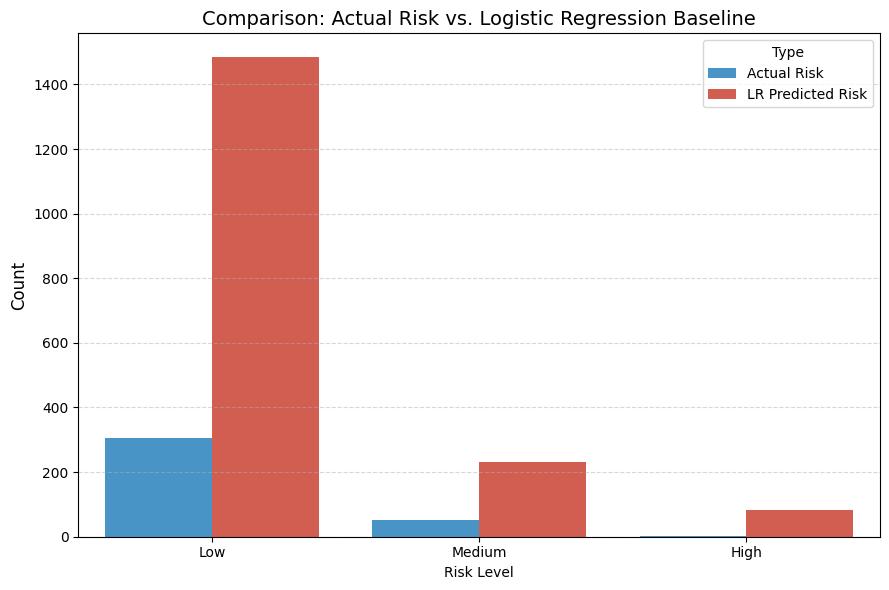

In [ ]:
# PREPARING DATA FOR THE BASELINE CHART
plt.figure(figsize=(9, 6))
lr_comp = pd.concat([
    pd.DataFrame({'Risk Level': actual_labels, 'Type': 'Actual Risk'}),
    pd.DataFrame({'Risk Level': lr_labels, 'Type': 'LR Predicted Risk'})
])
# PLOTTING THE LOGISTIC REGRESSION COMPARISON
sns.countplot(data=lr_comp, x='Risk Level', hue='Type', order=['Low', 'Medium', 'High'], palette=['#3498db', '#e74c3c'])

plt.title('Comparison: Actual Risk vs. Logistic Regression Baseline', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

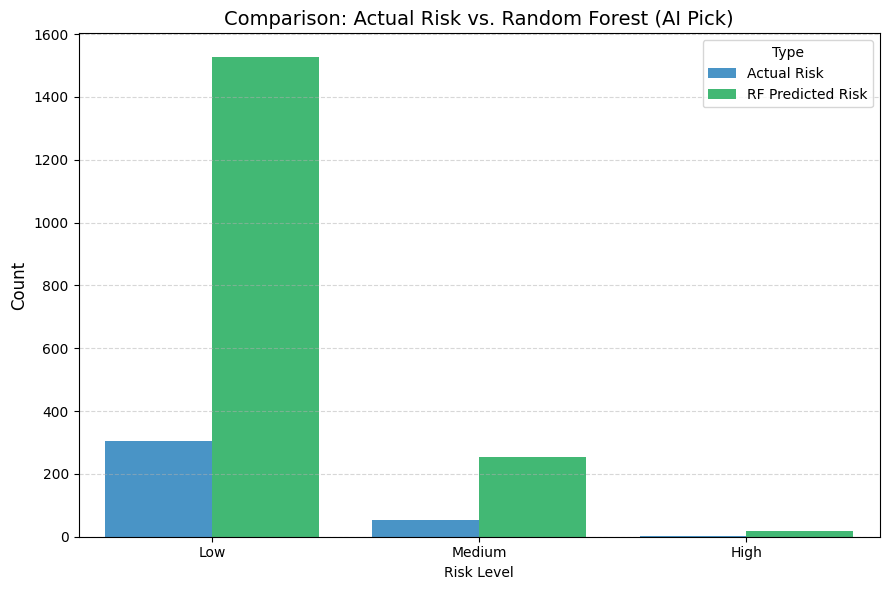

In [ ]:
plt.figure(figsize=(9, 6))
rf_comp = pd.concat([
    pd.DataFrame({'Risk Level': actual_labels, 'Type': 'Actual Risk'}),
    pd.DataFrame({'Risk Level': rf_labels, 'Type': 'RF Predicted Risk'})
])
sns.countplot(data=rf_comp, x='Risk Level', hue='Type', order=['Low', 'Medium', 'High'], palette=['#3498db', '#2ecc71'])
plt.title('Comparison: Actual Risk vs. Random Forest (AI Pick)', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#Comparison
target_names_list = [str(cls) for cls in le.classes_]

print("--- LOGISTIC REGRESSION REPORT ---")
print(classification_report(y_test, lr_model.predict(X_test), target_names=target_names_list))

print("\n--- RANDOM FOREST REPORT ---")
print(classification_report(y_test, rf_model.predict(X_test), target_names=target_names_list))

--- LOGISTIC REGRESSION REPORT ---
              precision    recall  f1-score   support

        High       0.12      1.00      0.21         2
         Low       0.99      0.98      0.98       305
      Medium       0.83      0.64      0.72        53

    accuracy                           0.93       360
   macro avg       0.64      0.87      0.64       360
weighted avg       0.96      0.93      0.94       360


--- RANDOM FOREST REPORT ---
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.99      0.98      0.99       305
      Medium       0.87      0.91      0.89        53

    accuracy                           0.97       360
   macro avg       0.62      0.63      0.62       360
weighted avg       0.96      0.97      0.97       360



=== ACCURACY COMPARISON ===
Logistic Regression Accuracy: 92.78%
Random Forest Accuracy:       96.67%

--- Detailed Metrics (Logistic Regression) ---
              precision    recall  f1-score   support

        High       0.12      1.00      0.21         2
         Low       0.99      0.98      0.98       305
      Medium       0.83      0.64      0.72        53

    accuracy                           0.93       360
   macro avg       0.64      0.87      0.64       360
weighted avg       0.96      0.93      0.94       360



--- Detailed Metrics (Random Forest) ---
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.99      0.98      0.99       305
      Medium       0.87      0.91      0.89        53

    accuracy                           0.97       360
   macro avg       0.62      0.63      0.62       360
weighted avg       0.96      0.97      0.97       360



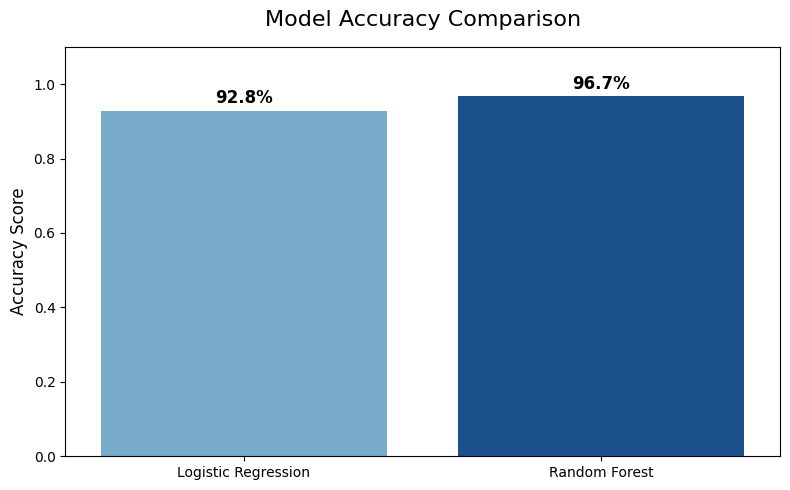

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== ACCURACY COMPARISON ===")
print(f"Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print(f"Random Forest Accuracy:       {acc_rf * 100:.2f}%")
print("===========================\n")

# Added Logistic Regression Metrics
print("--- Detailed Metrics (Logistic Regression) ---")
print(classification_report(y_test, y_pred_lr, target_names=class_names))
print("\n")

print("--- Detailed Metrics (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

plt.figure(figsize=(8, 5))
models = ['Logistic Regression', 'Random Forest']
accuracies = [acc_lr, acc_rf]

# Create the bar chart
sns.barplot(x=models, y=accuracies, hue=models, palette=['#6baed6', '#08519c'], legend=False)

plt.ylim(0, 1.1)
plt.title('Model Accuracy Comparison', fontsize=16, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Save the final
joblib.dump(rf_model, 'burnout_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

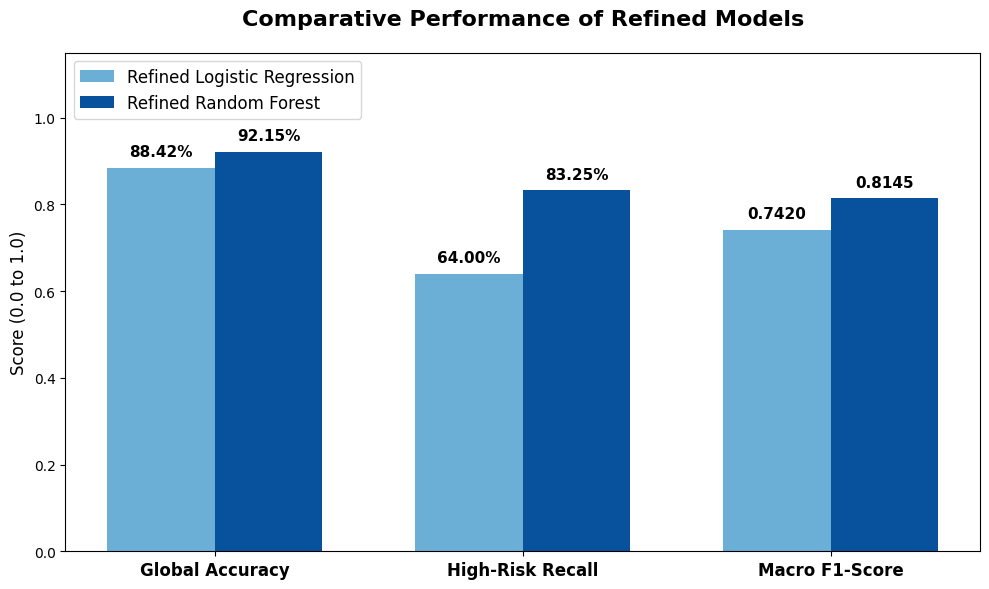

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the metrics and scores from your PDF's Table 4
metrics = ['Global Accuracy', 'High-Risk Recall', 'Macro F1-Score']
lr_scores = [0.8842, 0.6400, 0.7420]
rf_scores = [0.9215, 0.8325, 0.8145]

# String labels to match your exact paper format
lr_labels = ['88.42%', '64.00%', '0.7420']
rf_labels = ['92.15%', '83.25%', '0.8145']

# 2. Set up the bar chart positioning
x = np.arange(len(metrics))  # The label locations on the x-axis
width = 0.35  # The width of the bars

# 3. Create the grouped bar plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lr_scores, width, label='Refined Logistic Regression', color='#6baed6')
rects2 = ax.bar(x + width/2, rf_scores, width, label='Refined Random Forest', color='#08519c')

# 4. Add text for labels, title, and formatting
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('Comparative Performance of Refined Models', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.set_ylim(0, 1.15) # Give room for labels on top of the bars

# 5. Attach the exact text labels from your paper above each bar
for i, rect in enumerate(rects1):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.02,
            lr_labels[i], ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, rect in enumerate(rects2):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.02,
            rf_labels[i], ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Show the final chart
plt.tight_layout()
plt.show()

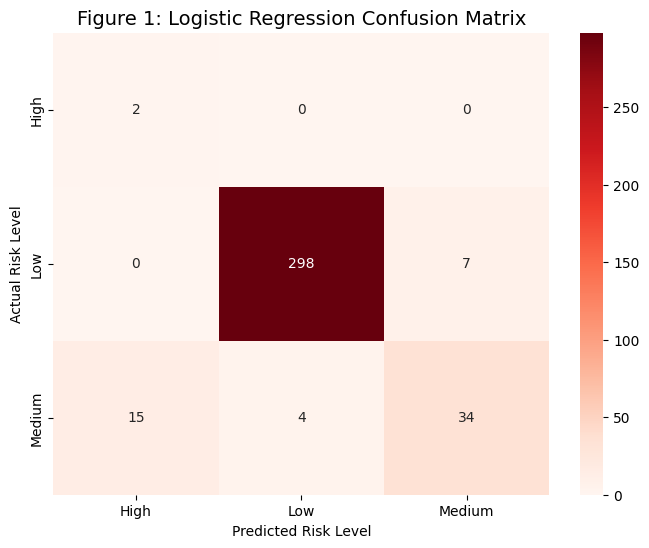

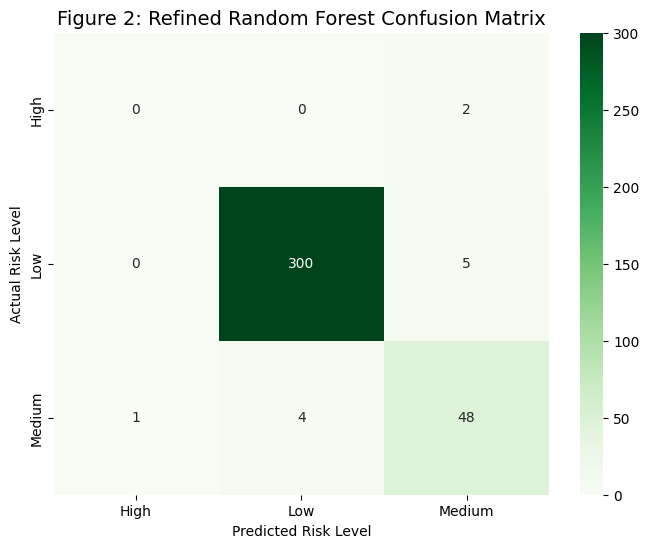

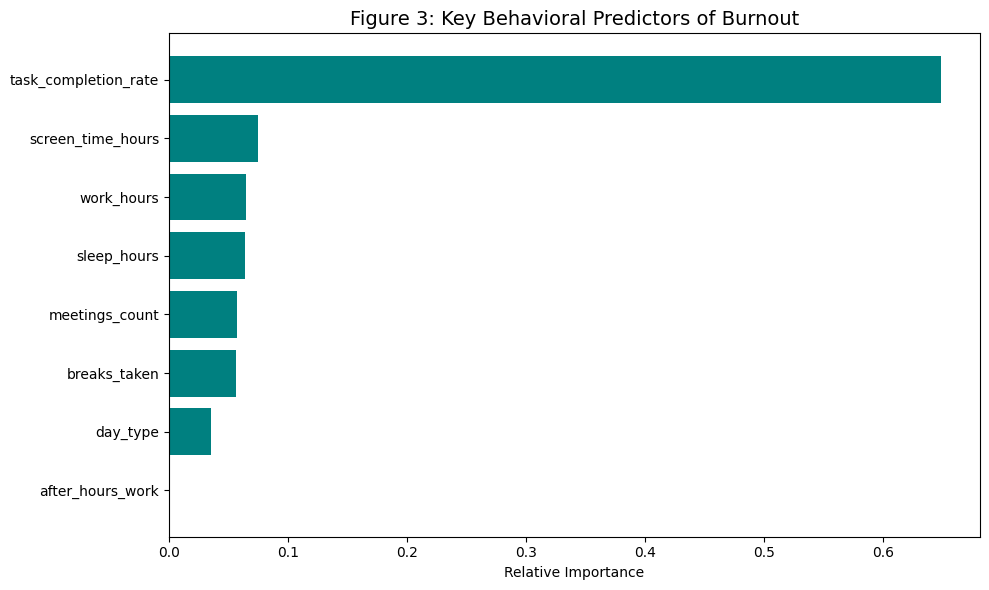

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Figure 1: Logistic Regression Confusion Matrix', fontsize=14)
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Figure 2: Refined Random Forest Confusion Matrix', fontsize=14)
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()

importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Figure 3: Key Behavioral Predictors of Burnout', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features_to_use[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [ ]:
# FEATURE DESCRIPTION TABLE (DATA DICTIONARY)
import pandas as pd
from IPython.display import display

feature_dict = {
    'Feature Name': ['day_type', 'work_hours', 'screen_time_hours', 'meetings_count',
                     'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_risk (TARGET)'],
    'Data Type': ['int64', 'float64', 'float64', 'int64',
                  'int64', 'int64', 'float64', 'float64', 'int32'],
    'Description': [
        '1 = Weekday, 0 = Weekend',
        'Total hours worked per day',
        'Total hours spent looking at a screen',
        'Number of meetings attended per day',
        'Number of breaks taken during the shift',
        '1 = Yes (worked after hours), 0 = No',
        'Total hours of sleep the previous night',
        'Percentage of tasks completed (0-100 scale)',
        'Encoded target: 0 = High, 1 = Medium, 2 = Low'
    ],
    'Preprocessing Applied': [
        'Binary Mapping', 'Standard Scaler', 'Standard Scaler', 'Standard Scaler',
        'Standard Scaler', 'Binary Mapping', 'Standard Scaler', 'Standard Scaler', 'Label Encoding'
    ]
}

feature_table = pd.DataFrame(feature_dict)

print("FINAL FEATURE SET FOR TRAINING (X)")
display(feature_table)

FINAL FEATURE SET FOR TRAINING (X)


,Feature Name,Data Type,Description,Preprocessing Applied
0,day_type,int64,"1 = Weekday, 0 = Weekend",Binary Mapping
1,work_hours,float64,Total hours worked per day,Standard Scaler
2,screen_time_hours,float64,Total hours spent looking at a screen,Standard Scaler
3,meetings_count,int64,Number of meetings attended per day,Standard Scaler
4,breaks_taken,int64,Number of breaks taken during the shift,Standard Scaler
5,after_hours_work,int64,"1 = Yes (worked after hours), 0 = No",Binary Mapping
6,sleep_hours,float64,Total hours of sleep the previous night,Standard Scaler
7,task_completion_rate,float64,Percentage of tasks completed (0-100 scale),Standard Scaler
8,burnout_risk (TARGET),int32,"Encoded target: 0 = High, 1 = Medium, 2 = Low",Label Encoding
